In [63]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile

### 0. Recapping Math

##### 0.1 Complex Number Space

Remember for the $x$-axis (real component) and $y$-axis (imaginary component),

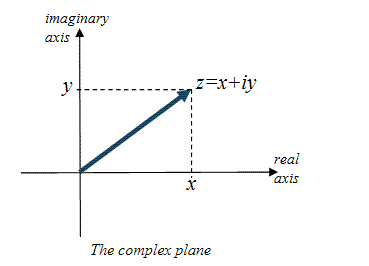

This can be represented as a $2\times2$ matrix, where $(x, y) = (a, b)$,

$z = a + bi \; \widehat{=} \begin{bmatrix}a & -b \\ b & a \end{bmatrix}$

##### 0.2 Denoting as 3-Dimensional Space in $2\times2$

Using the Pauli matrices to denote $\vec{v}=(x,y,z)$, we get,

$\rho = x\sigma_1 + y\sigma_2 + z\sigma_3$

In which the Pauli matrices can be denoted as,

$\sigma_1 = \begin{bmatrix}0 & 1 \\ 1 & 0 \end{bmatrix}$, $\sigma_2 = \begin{bmatrix}0 & -i \\ i & 0 \end{bmatrix}$, $\sigma_3 = \begin{bmatrix}1 & 0 \\ 0 & -1 \end{bmatrix}$

Thus can be denoted as,

$\rho = \begin{bmatrix}z & x -iy \\ x + iy & -z \end{bmatrix}$

##### 0.3 Determing the Probabilities with Bloch Sphere

###### Referencing the Bloch Sphere

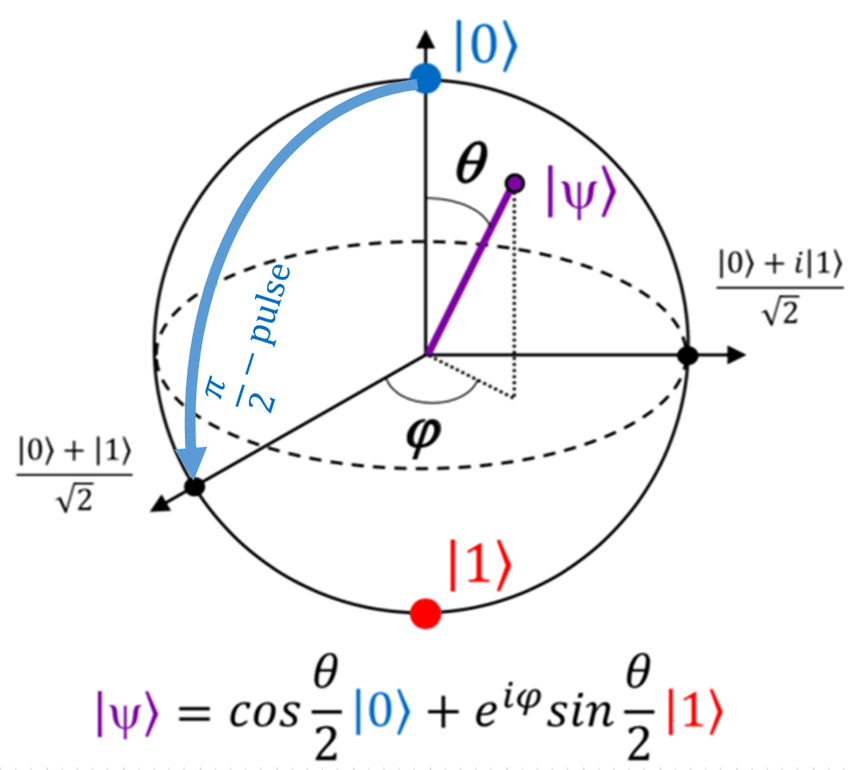

Denoting the Bloch sphere for calculations,

$|\psi⟩ = \cos\!\left(\frac{\theta}{2}\right)\,|0⟩ + e^{i\phi}\,\sin\!\left(\frac{\theta}{2}\right)\,|1⟩$

Recalling the complex number $z$,

$|\psi⟩ = a|0⟩ + b|1⟩$, where $a = \cos\!\left(\frac{\theta}{2}\right)\,$ and $b = e^{i\phi}\,\sin\!\left(\frac{\theta}{2}\right)\,$.

###### Calculating Probabilities

To determine the probabilities, let $N$ be the total counts of repeated measurements of the Qubit, where,

$N = n_0 + n_1$

Thus,

$\hat{P}(0) = \frac{n_0}{N}$ and $\hat{P}(1) = \frac{n_1}{N}$

Both denoting the probabilities of being `0` or `1` classical bit. _Note that if $\hat{P}(1) > \hat{P}(0)$ one cannot claim it is equals `1`, rather it is *biased* toward `1`, and for classical interpretation, it is considered as `1`._

###### Error Reduction with Measurements

Thus, given that the interpretation is probabilistic, it is ideal to take more measurements to determine a better accuracy,

$error \sim \frac{1}{\sqrt{N}}$

| Shots($N$) | Typical Error |
| -- | -- |
| 100 | ~10% |
| 1,000 | ~3% |
| 10,000 | ~1% |
| 1,000,000 | ~0.1% |

In [64]:
Aer.backends()

[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

### 1. Phase
#### 1.1 Starting with the $Z$ Phase Gate

> Shifts the phase (a complex number component) of the Qubit's state (e.g. from $a + bi$ to $a - bi$).

Refer to: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.ZGate

Matrix representation:

$
Z = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$

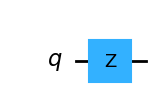

In [65]:
qc = QuantumCircuit(1)
qc.z(0)
qc.draw('mpl')

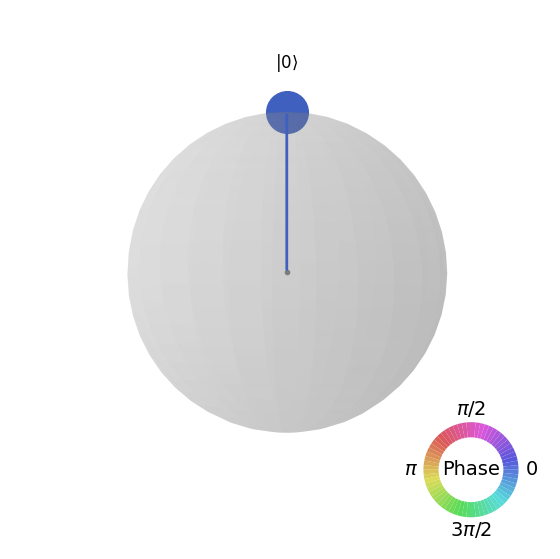

In [66]:
state = Statevector.from_instruction(qc)
plot_state_qsphere(state)

#### 1.2 Adding the $H$ (Hadamard) Gate

> Fundamental quantum operation used to put a qubit into an equal superposition of $|0⟩$ and $|1⟩$ (both states at once), enabling quantum parallelism and interference

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.HGate

$
H = \frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$

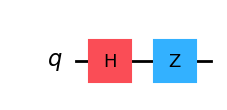

In [67]:
qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)
qc.draw('mpl')

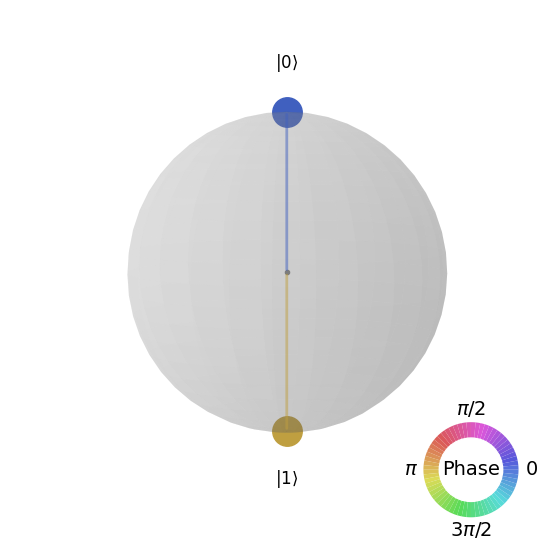

In [68]:
state = Statevector.from_instruction(qc)
plot_state_qsphere(state)

### 2. Phase and Bloch Sphere
#### 2.1 Running on Simulators

In [69]:
import math
from qiskit.quantum_info import DensityMatrix, Statevector

In [70]:
qasm_simulator = Aer.get_backend('qasm_simulator')
statevector_simulator = Aer.get_backend('statevector_simulator')

In [71]:
def run_on_simulators(circuit):
    compiled_circuit = transpile(circuit, backend=statevector_simulator)
    job = statevector_simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    statevec = result.get_statevector()
    num_qubits = circuit.num_qubits
    # r = [i for i in range(num_qubits)]
    # circuit.measure(r, r)
    circuit.measure_all()
    return result, statevec or Statevector([])

#### 2.2 Running with $RX$ Rotate-$x$ Gate

> Rotates a qubit's state around the $x$-axis of the Qubit's Bloch sphere by a specified angle ($θ$), acting as a fundamental tool for state preparation, creating superpositions, and manipulating quantum information in quantum algorithms.

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXGate

Matrix:

$
RX(θ) = \begin{bmatrix}
cos(θ/2) & -i sin(θ/2) \\
-i sin(θ/2) & cos(θ/2)
\end{bmatrix}
$

---

For the $RY$ Rotate-$y$ Gate on the $y$-axis,

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RYGate

Matrix:

$
RY(θ) = \begin{bmatrix}
cos(θ/2) & -sin(θ/2) \\
sin(θ/2) & cos(θ/2)
\end{bmatrix}
$

---

For the $RZ$ Rotate-$z$ Gate on the $z$-axis,

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RZGate

Matrix:

$
RZ(φ) = \begin{bmatrix}
e^{-i\frac{φ}{2}} & 0 \\
0 & e^{i\frac{φ}{2}}
\end{bmatrix}
$





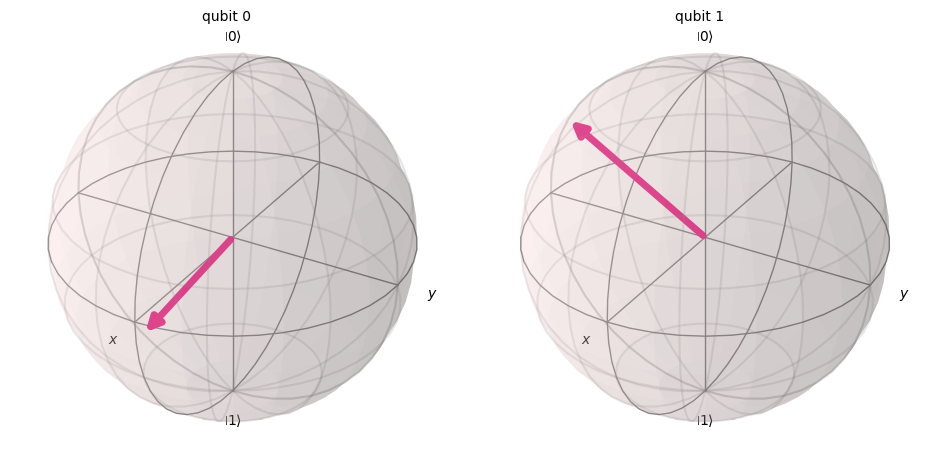

In [72]:
qc = QuantumCircuit(2,2)
qc.rx(-1.2*math.pi, 0)
qc.rx(math.pi/3, 1)
result, statevec = run_on_simulators(qc)
plot_bloch_multivector(statevec)

#### 2.3 Understanding Phase Gate

1. Use Hadamard Gate itself first
2. Apply Phase Gate to see switch in direction

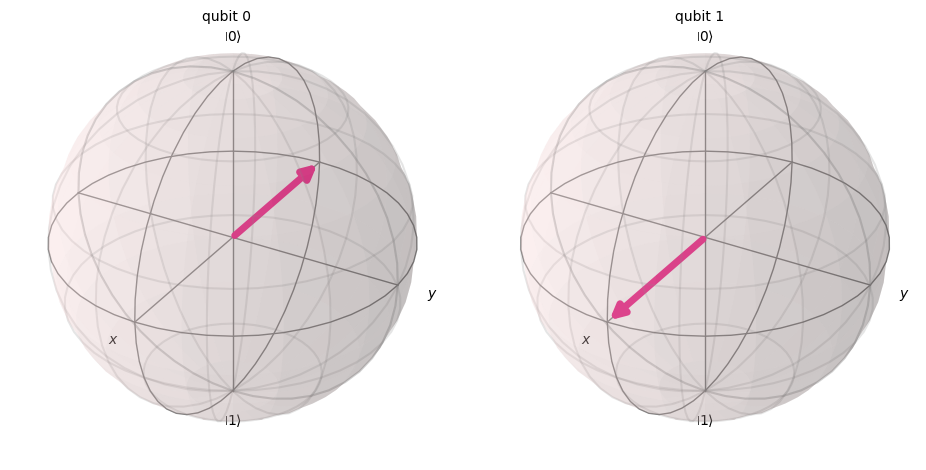

In [73]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.z(0)
qc.h(1)
result, statevec = run_on_simulators(qc)
plot_bloch_multivector(statevec)

#### 2.5 Using the CNOT (Controlled NOT) Gate

> Fundamental two-qubit quantum logic gate that flips the state of a "target" qubit only if a "control" Qubit is in the $|1⟩$ state. This is also known as the Controlled Pauli-X Gate

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CXGate

Matrix:

$
CX q_0, q_1 = I ⊗ ∣0⟩⟨0∣ + X ⊗ ∣1⟩⟨1∣ = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
$

Recall that $⊗$ is a tensor product,

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\otimes
\begin{bmatrix}
e & f \\
g & h
\end{bmatrix}
=
\begin{bmatrix}
ae & af & be & bf \\
ag & ah & bg & bh \\
ce & cf & de & df \\
cg & ch & dg & dh
\end{bmatrix}
$$

In [74]:
qc = QuantumCircuit(2,2)
qc.h(0)
#qc.rx(math.pi * 4/5, 0)
result, statevec = run_on_simulators(qc)
print(result.get_counts())

{'00': 1024}


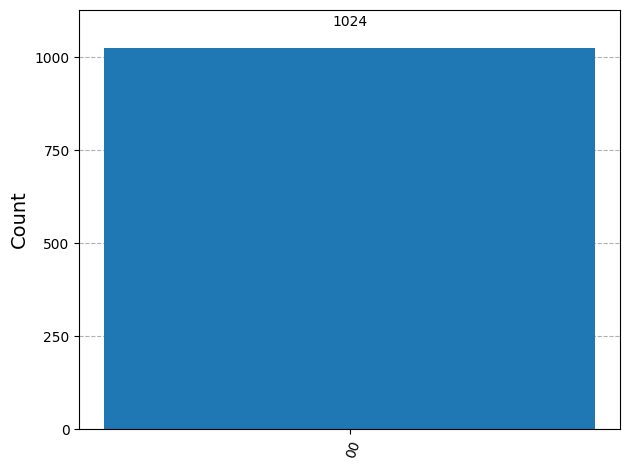

In [75]:
plot_histogram(result.get_counts())

In [76]:
qc.cx(0, 1)
result, statevec = run_on_simulators(qc)
print(result.get_counts())

{'00 00': 519, '01 00': 505}


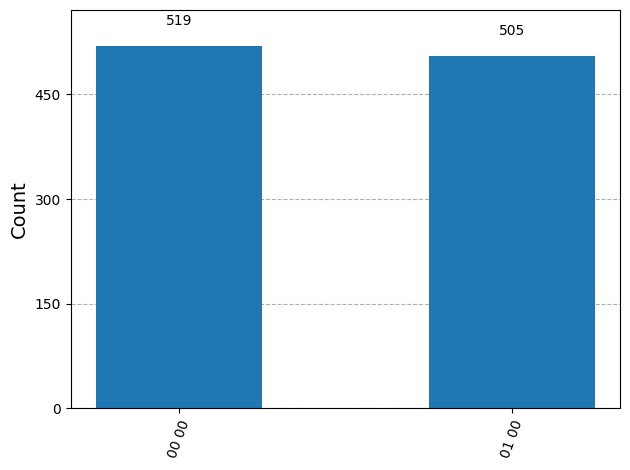

In [77]:
plot_histogram(result.get_counts())

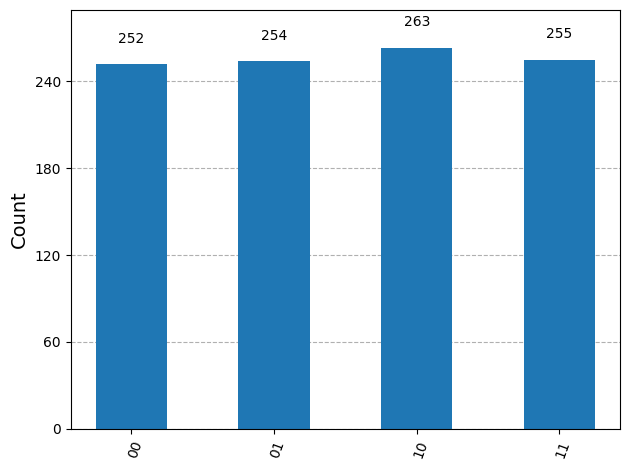

In [78]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.h(1)
qc.measure([0, 1], [0, 1])
result, statevec = run_on_simulators(qc)
plot_histogram(result.get_counts())

### 3. Superdense Coding

Alice and Bob starts with a shared Bell pair and choose 2 bits, and for Bob to recover Alice's selected bits, he has to apply a CNOT + H operation (e.g. opposite of result and switching the result into compoutational basis from superposition state).

- Identity Gate: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.IGate
- Pauli X Gate: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.XGate
- Pauli Z Gate: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.ZGate

----

1. **T0**: Apply a Hadamard $H$ Gate to set to superposition and then $CNOT$ to create entanglement from Alice's q0 to Bob's q1.
2. **T1**: Apply computations for the desired outcome on Bob's q1.
3. **T2**: Apply $CNOT$ and then $H$ Gate (to end the superposition state) to receive the message result.

Imagine where,

$|ab⟩ + |cd⟩$

Below are the operations for apply
| Gate | | Rotation | Bell State | Alice<br>Flip | Post-CNOT Operation | Bob<br>Flip | Post-H Operation |
| -- | -- | -- | -- | -- | -- | -- | -- | 
| Identity Gate | $I = \begin{bmatrix}1&0\\0&1\end{bmatrix}$ | - | $\|Φ+⟩ → \frac{1}{\sqrt{2}}(\|00⟩ + \|11⟩)$ | - | $\frac{1}{\sqrt{2}}(\|00⟩ + \|10⟩)$ | $d$ | $00$ |
| Pauli X Gate | $X = \begin{bmatrix}0&1\\1&0\end{bmatrix}$  | $$R_x(π)$$ | $\|Ψ+⟩ → \frac{1}{\sqrt{2}}(\|10⟩ + \|01)$ | $a$, $c$ | $\frac{1}{\sqrt{2}}(\|11⟩ + \|01⟩)$ | $b$ | $01$ |
| Pauli Z Gate | $Z = \begin{bmatrix}1&0\\0&-1\end{bmatrix}$ | $$R_z(π)$$ | $\|Φ-⟩ → \frac{1}{\sqrt{2}}(\|00⟩ - \|11⟩)$ | - | $\frac{1}{\sqrt{2}}(\|00⟩ - \|10⟩)$ | $d$ | $10$ |
| Pauli X then Z Gate | $X \cdot Z = \begin{bmatrix}0&-1\\1&0\end{bmatrix}$ | $e^{-i\frac{\pi}{2}} R_y(\pi)$ | $\|Ψ-⟩ → \frac{1}{\sqrt{2}}(\|10⟩ - \|01)$ | $a$, $c$ | $\frac{1}{\sqrt{2}}(\|11 - \|01)$ | $b$ | $11$ |

---

For this operations, it does not include the Pauli Y Gate, which rotates as $R_y(π)$, although for reference in terms of relations,

$Y = \begin{bmatrix}0&-i\\i&0\end{bmatrix}$ 

Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.YGate

In [79]:
class SuperDense:

    def __init__(self):
        # Sharing of the Bell pair (H + CNOT)
        self.qc = QuantumCircuit(2, 2)
        self.qc.h(0)
        self.qc.cx(0, 1)
        self.qc.barrier(label="T0")
    
    def encode(self, message_bits):
        # Identity means nothing
        if message_bits == "00":
            pass
        # Pauli X Gate application
        elif message_bits == "10":
            self.qc.x(0)
        # Pauli Z Gate application
        elif message_bits == "01":
            self.qc.z(0)
        # Pauli X then Z Gate application
        elif message_bits == "11":
            self.qc.x(0)
            self.qc.z(0)

        self.qc.barrier(label="T1")

    def decode(self):
        self.qc.cx(0, 1)
        self.qc.h(0)
        self.qc.barrier(label="T2")
    
    def measure(self):
        # Each call collapses the state and mutates the circuit, so create a copy to not mutate the original circuit
        measured = self.qc.copy()
        measured.measure([0,1], [0,1])
        result, _ = run_on_simulators(measured)
        counts = result.get_counts()
        decoded = max(counts, key=counts.get)
        return decoded

Alice sends `00` message to Bob:

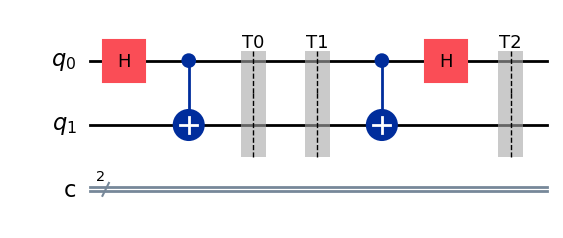

In [80]:
sd = SuperDense()
sd.encode('00')
sd.decode()
sd.qc.draw("mpl")

In [81]:
print('Decoded:', sd.measure())

Decoded: 00


Alice sends `10` message to Bob:

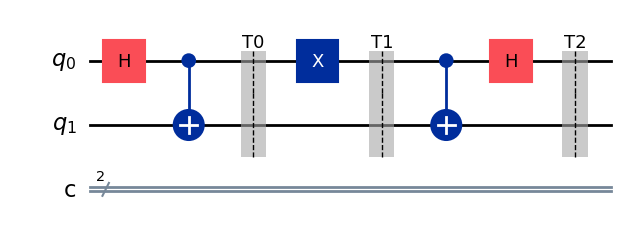

In [82]:
sd = SuperDense()
sd.encode('10')
sd.decode()
sd.qc.draw("mpl")

In [83]:
print('Decoded:', sd.measure())

Decoded: 10


Alice sends `01` message to Bob:

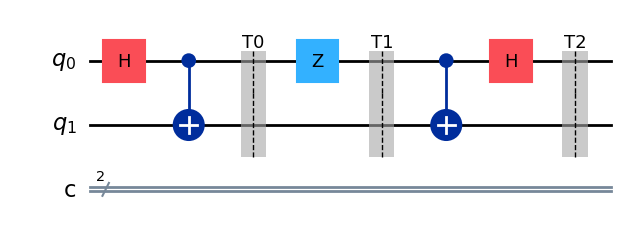

In [84]:
sd = SuperDense()
sd.encode('01')
sd.decode()
sd.qc.draw("mpl")

In [85]:
print('Decoded:', sd.measure())

Decoded: 01


Alice sends `11` message to Bob:

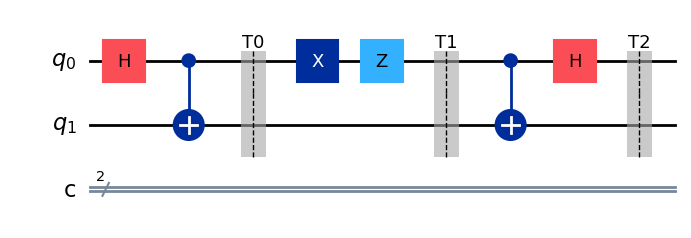

In [86]:
sd = SuperDense()
sd.encode('11')
sd.decode()
sd.qc.draw("mpl")

In [87]:
print('Decoded:', sd.measure())

Decoded: 11


### 4. Quantum Teleportation

For Superdense coding, it is sending **2 classical bits** via **1 qubit** using the shared entanglement. Alice applies a gate and sends her qubit, and Bob decodes from it.

For Telportation, it is sending **1 qubit state** via **2 classical bits** using the shared entanglement. Alice measures and sents the 2 bits, and Bob applies the relevant corrections. _Think of it as the opposite action._

##### 4.1 Setting a Qubit State

Let Alice set a Qubit state on q0 such that,

$
|\psi⟩ = a|0⟩ + b|1⟩
$

Bob's Qubit q2 would be entangled to q1, in which q1 measures q0.

##### 4.2 Measurement of States

| | q0 | q2| Action | | | Result |
| -- | -- | -- | -- | -- | -- | -- |
| 00 | - | $\|00⟩$ | $I$ | $\|Φ+⟩ → a\|0⟩ + b\|1⟩$ | Apply nothing | $\hat{P}(0) = 1$. |
| 01 | Set $X$ | $\|01⟩$ | $X$ | $\|Ψ+⟩ → a\|1⟩ + b\|0⟩$ | Apply $X$ only | $\hat{P}(1) = 1$ (as it swaps $\|0⟩$ with $\|1⟩$) |
| 10 | Set $H$ | $\|10⟩$ | $Z$ | $\|Φ-⟩ → a\|0⟩ - b\|1⟩$ | Apply $Z$ only | $\hat{P}(1) \approx 0.5$ |
| 11 | Set $RZ(\frac{\pi}{5})$ and $RY(\frac{\pi}{3})$ | $\|11⟩$ | $X \cdot Z$ | $\|Ψ-⟩ → a\|1⟩ - b\|0⟩$ | Apply $X$ then $Z$ | $\hat{P}(0) \approx \frac{3}{4}$ and $\hat{P}(1) \approx \frac{1}{4}$ |

Apply the measurement from q0 to q1, which should result q2 to become the particular values.

_Note as we are running in simulation, deferred measurement is used as assumed_

1. **T0**: 

In [88]:
import numpy as np
from qiskit_aer import AerSimulator

In [89]:
class QuantumTeleportation:

    def __init__(self, message_bits):
        self.qc = QuantumCircuit(3, 3)
        # Step 2) Set the quantum state to teleport
        self.qc.barrier(label="T0")

        if message_bits == '00':
            pass 
        elif message_bits == '01':
            self.qc.x(0)
        elif message_bits == '10':
            self.qc.h(0)
        elif message_bits == '11':
            self.qc.ry(np.pi/3, 0)
            self.qc.rz(np.pi/5, 0)

    def teleport(self):
        self.qc.barrier(label="T1")
        self.qc.h(1)
        self.qc.cx(1, 2)

        self.qc.barrier(label="T2")
        self.qc.cx(0, 1)
        self.qc.h(0)
        # self.qc.barrier(label="measurement")
        # self.qc.measure(0, 0)
        # self.qc.measure(1, 1)

        self.qc.barrier(label="T3")

        # with self.qc.if_test((self.qc.clbits[1], 1)):
        #     self.qc.x(2)

        # with self.qc.if_test((self.qc.clbits[0], 1)):
        #     self.qc.z(2)

        # self.qc.barrier(label="simulator")
        self.qc.cx(1, 2)
        self.qc.cz(0, 2)

        # Deferred measurement
        self.qc.barrier(label="T4")
        self.qc.measure([0, 1], [0, 1])
        self.qc.measure([2], [2])

    def measure(self):
        backend = AerSimulator()
        # self.qc.save_statevector() # Snapshot the state after corrections
        qc_copy = self.qc.copy()
        result = backend.run(qc_copy).result()
        counts = result.get_counts()

        bucket = {'0':0, '1':0}
        for bitstring, n in counts.items():
            bucket[bitstring[0]] += n

        print(f"p0 = {(bucket['0'] / sum(counts.values())) * 100}%")
        print(f"p1 = {(bucket['1'] / sum(counts.values())) * 100}%")

        return plot_histogram(counts)
    

Teleport state for `00`,

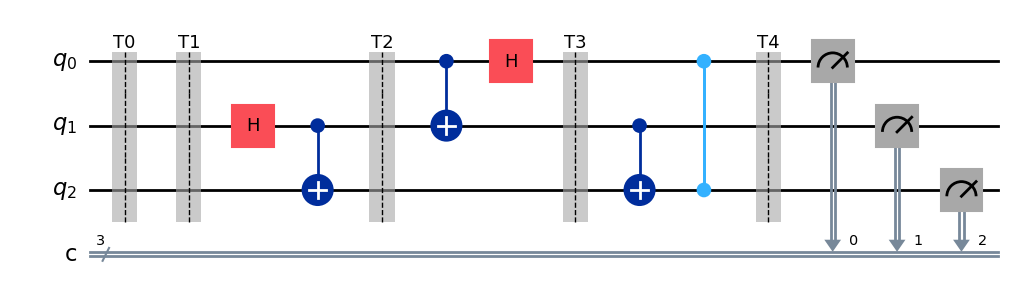

In [90]:
qt = QuantumTeleportation('00')
qt.teleport()
qt.qc.draw("mpl")

p0 = 100.0%
p1 = 0.0%


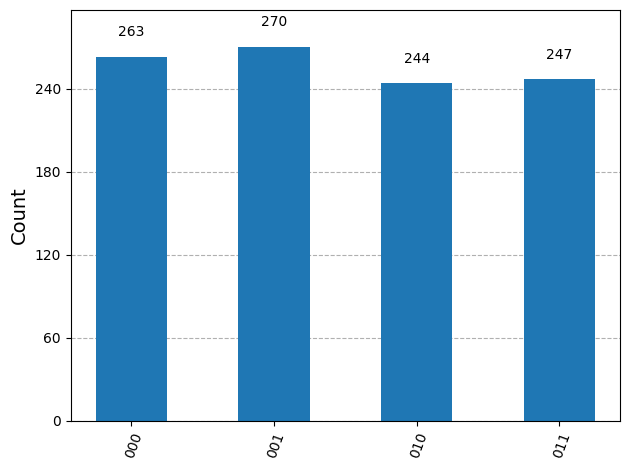

In [91]:
qt.measure()

Teleport state for `01`,

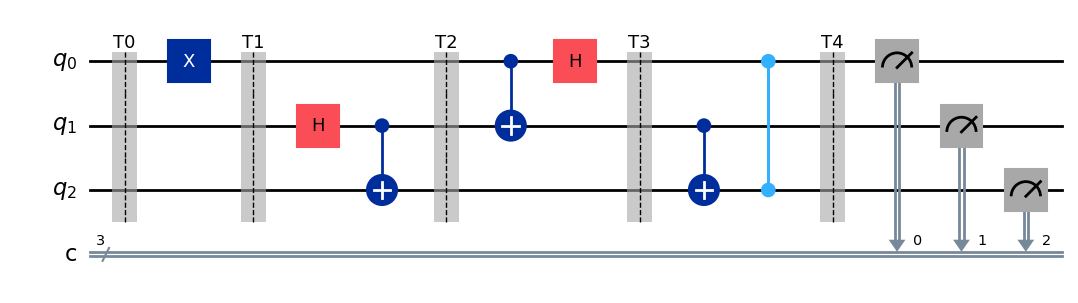

In [92]:
qt = QuantumTeleportation('01')
qt.teleport()
qt.qc.draw("mpl")

p0 = 0.0%
p1 = 100.0%


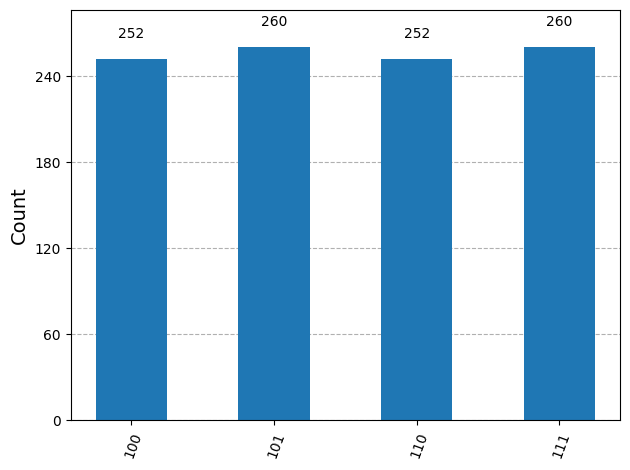

In [93]:
qt.measure()

Teleport state for `10`,

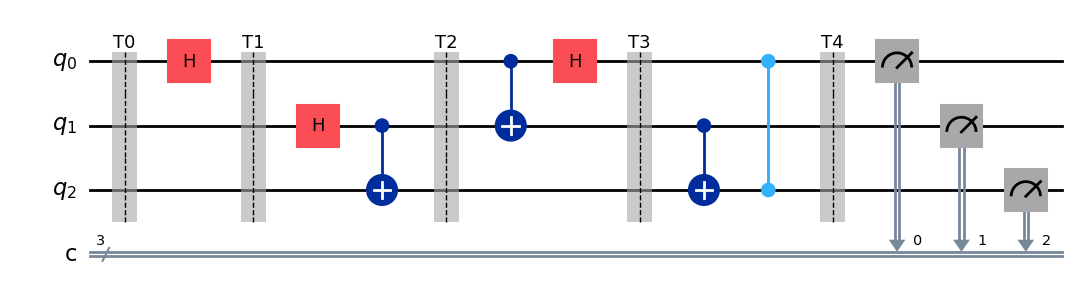

In [94]:
qt = QuantumTeleportation('10')
qt.teleport()
qt.qc.draw("mpl")

p0 = 48.828125%
p1 = 51.171875%


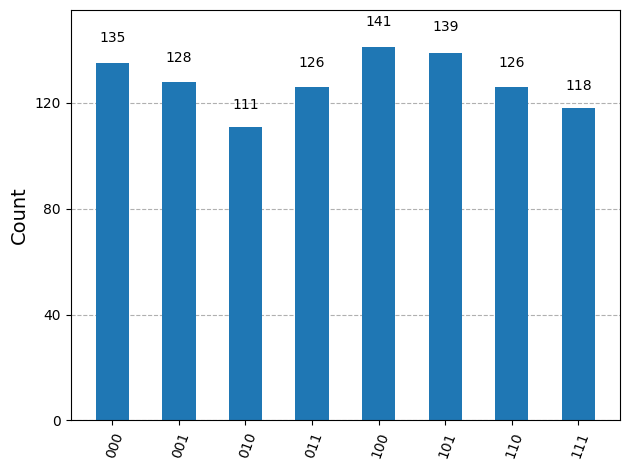

In [95]:
qt.measure()

Teleport state for `11`,

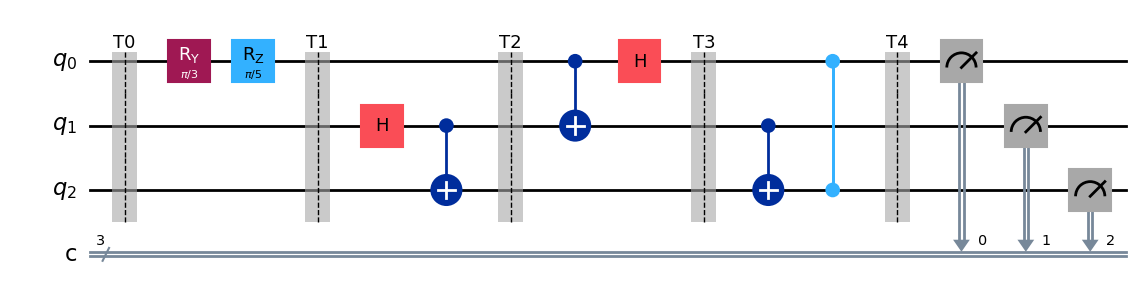

In [96]:
qt = QuantumTeleportation('11')
qt.teleport()
qt.qc.draw("mpl")

p0 = 73.046875%
p1 = 26.953125%


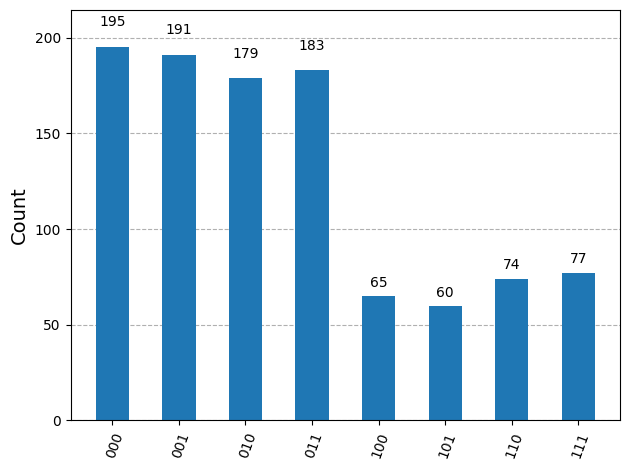

In [97]:
qt.measure()